实验思想：背景与原理

1.1 Grokking 现象
Grokking 由 Power et al. (2022) 在研究小型算法数据集上的神经网络泛化时发现：模型先在训练集上完美记忆，之后经过远超过拟合点的额外训练，测试精度才突然从随机水平跳跃至完美泛化。这一现象在模块化算术（如模加法 (a+b) mod p(a + b) \bmod p
(a+b)modp、模乘法）、群运算等代数任务上表现尤为显著，且训练数据量通常较少（约占全集的 30%
—50%）。Power et al. 发现，Weight Decay 是影响 grokking 出现与否的关键因素：无 Weight Decay 时模型停留在记忆状态，加入 Weight Decay 后泛化才会出现。

1.2 Rank 与泛化的联系
Yunis et al. (2024a) 在 ICML MI Workshop 上提出了 grokking 与低秩权重之间的联系。他们的核心发现是：

grokking 中泛化转变的时机与网络发现低秩解同时发生。

具体地，他们追踪了训练过程中权重矩阵奇异值的演化，发现有效秩（stable rank）的突然下降与测试精度的突然提升在时间上高度吻合，而且 Weight Decay 的强度控制了这种低秩趋势的速度。记忆解对应高秩权重，泛化解对应低秩权重，两者在奇异值谱上有可区分的特征。
Yunis et al. (2024b) 在更大规模的工作中进一步发现，这种**低秩偏向（low-rank bias）**是深度学习优化过程中的普遍现象，跨越了图像分类（ConvNet）、语音识别（LSTM）、图像生成（UNet）和语言模型（Transformer）等不同任务。他们的关键结论是：Weight Decay 超越了其作为范数正则化器的作用，额外强化了这种低秩偏向，即使在大规模实际系统中也成立。这意味着 Weight Decay 不只是让权重变小，它在改变权重矩阵的方向结构（奇异值分布）。

1.3 为什么 rank（秩）和泛化有关？这里，我们作出假设是：权重矩阵的秩代表了模型表示知识的复杂度。低秩的权重矩阵意味着模型用更少的“自由度”表达同样的函数，对应更简洁、更可泛化的解。为了诱导模型更早的变为低rank的结构，我们设计了一种新的正则器lrd。仔细说明如下：
形式化地，权重矩阵 $W \in \mathbb{R}^{m \times n}$ 的奇异值分解（SVD）为：$$W = U \Sigma V^\top, \quad \Sigma = \text{diag}(\sigma_1, \sigma_2, \ldots, \sigma_r)$$核范数（Nuclear Norm）定义为所有奇异值之和：$$\|W\|_* = \sum_i \sigma_i(W)$$
 L2 的局限性：与 LRD（低秩衰减）的动机传统 L2 正则化惩罚的是权重的 Frobenius 范数：$$\mathcal{L}_{L2} = \lambda \|W\|_F^2 = \lambda \sum_{i,j} W_{ij}^2 = \lambda \sum_i \sigma_i^2$$这对所有奇异值施加均匀的二次惩罚，并不显式偏向低秩解——它倾向于让所有奇异值都变小，而不是让少数奇异值趋近于零。LRD（Low-Rank Decay）的出发点是：如果泛化解本质上是低秩的，那么应该直接惩罚核范数：$$\mathcal{L}_{LRD} = \lambda \|W\|_* = \lambda \sum_i \sigma_i(W)$$相比 L2 的二次惩罚，L1 风格的核范数惩罚对奇异值施加均匀的线性惩罚，会产生稀疏性（让小奇异值直接归零），从而诱导低秩结构。这类似于 Lasso 和 Ridge 回归的关系。
 除此之外，l2正则化在尺度不变网络中的不会改变模型的行为，在本次实验中，使用 RMSNorm + QK-Norm 的 Transformer。这类网络是尺度不变的：Attention 的输出只依赖于 $Q$、$K$ 的方向，而与它们的绝对大小无关：$$\text{Attn}(Q, K, V) = \text{softmax}\left(\frac{\hat{q}\hat{k}^\top}{\sqrt{d_h}}\right)V, \quad \hat{q} = \frac{q}{\|q\|}, \quad \hat{k} = \frac{k}{\|k\|}$$在这种设置下，L2 Weight Decay 会持续缩小 $\|W\|$，但不改变模型的实际行为。因此 L2 在理论上对尺度不变网络的泛化没有直接贡献。LRD 则通过改变权重矩阵的方向结构（即奇异值分布）来施加有效的正则化。
 
 LRD 的实现：LRD 通过极分解（Polar Decomposition）来近似：$$\nabla_W \|W\|_* = U V^\top \triangleq \text{polar}(W)$$其中 $UV^\top$ 是 $W$ 的极分解正交因子，满足 $W = UV^\top \Sigma$。也就是奇异值分解(SVD)为了避免昂贵的 SVD，可以用 Newton-Schulz 迭代来近似计算：$$X_0 = \frac{W}{\|W\|_F}, \quad X_{t+1} = \frac{1}{2} X_t (3I - X_t^\top X_t)$$迭代收敛后 $X \approx UV^\top$，即极分解因子（polar factor）。最终，LRD 的解耦更新（类似于 AdamW 的 decoupled weight decay）可以写为：$$W \leftarrow W - \eta \lambda \cdot \text{polar}(W)$$
## 2. 实验设置

### 2.1 任务设定
本实验涵盖 6 个不同复杂度的算法与逻辑任务，均采用固定测试集大小以保障公平性：

| 任务名称 | 简写 | 输入类型 | 数据量 | 任务特性 |
| :--- | :--- | :--- | :--- | :--- |
| **模加法 (Modular Addition)** | ModAdd | 二元输入 | ~9,000 条 | 基础代数运算 |
| **模乘法 (Modular Multiplication)** | ModMul | 二元输入 | ~9,000 条 | 基础代数运算 |
| **模对数 (Modular Log)** | ModLog | 二元输入 | ~9,000 条 | 复杂代数运算 |
| **模多项式 (Modular Polynomial)** | ModPoly | 二元输入 | ~9,000 条 | 复杂代数运算 |
| **群组合 (Group Composition)** | S5 Group | S5 置换群 | 14,400 条 | 120² 抽象代数结构 |
| **奇偶校验 (Parity)** | Parity | 16位序列 | 50,000 条 | 长序列逻辑判断 |

### 2.2 模型架构与优化器
* **骨干网络**：2 层 TinyTransformer（`dim=128`, `heads=4`）。
* **归一化策略**：RMSNorm + QK-Norm（确保尺度不变性）。
* **输出层**：Flatten 输出（无 Mean Pooling）。
* **优化器与超参**：AdamW + Muon，Gradient Clip = `0.5`。
* **正则化控制变量**：划分为**纯 L2**、**纯 LRD**、**L2 + LRD 混合(下面图表中成为elastic)**三组。所有正则化项均与梯度更新**完全解耦**。

---

## 3. 实验结果与评估

### 3.1 单元测试 (Unit Test)
在初步的小规模测试中，**LRD 在多个任务上表现出普遍的优越性**，能够更快、更稳定地诱发模型产生 Grokking。单元测试的结果在下面。

### 3.2 大规模超参数搜索 (HPO)
基于 `skopt` 的贝叶斯优化进行了大规模多种子（Multi-seed）搜索验证，结果呈现出任务分化：
1. **简单任务**：L2 和 LRD 均能促使模型快速收敛，无显著差异。
2. **复杂任务**：
    * LRD 在 **ModPoly (模多项式)** 任务上表现更优。
    * L2 在 **Parity (奇偶校验)** 和 **S5 Group (群组合)** 任务上表现出更强优势。



---

## 4. 结论
在严格公平的实验设置（解耦正则化、多种子超参数搜索、固定测试集大小、自适应 Newton-Schulz 修正）下：

LRD 相比 L2 没有绝对的优越性，在群组合等较难任务上的默认超参数设置下表现出加速效果。
Rank Collapse 是 Grokking 的伴随现象，optimizer + L2 weight decay 的交互作用同样足以诱导低秩解，与 Yunis et al. (2024b) 关于隐式低秩偏向的发现高度吻合。

单元测试结果：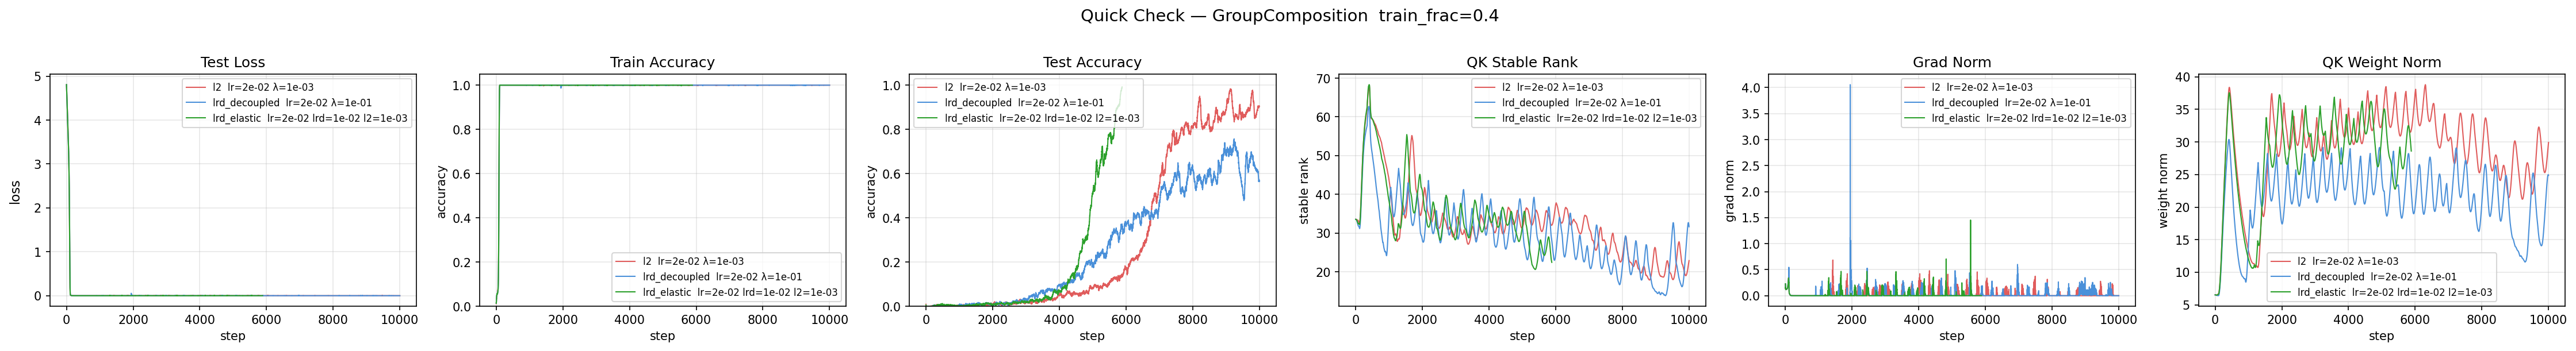

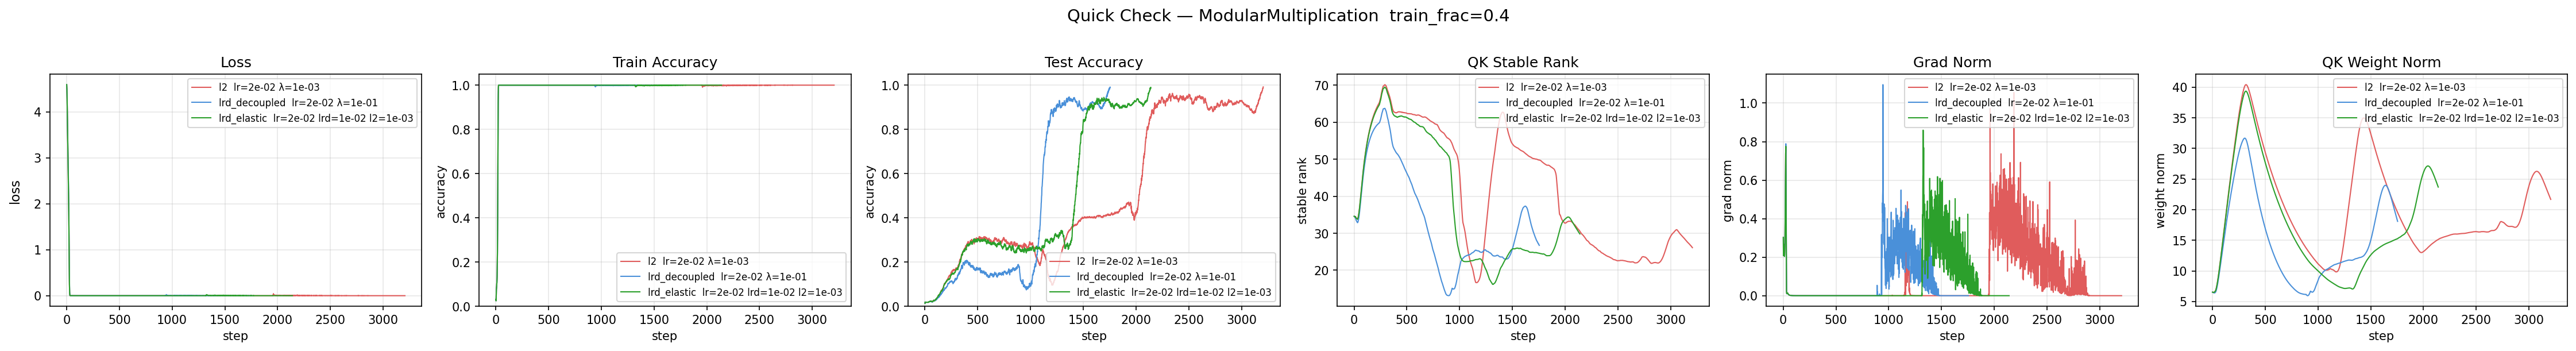 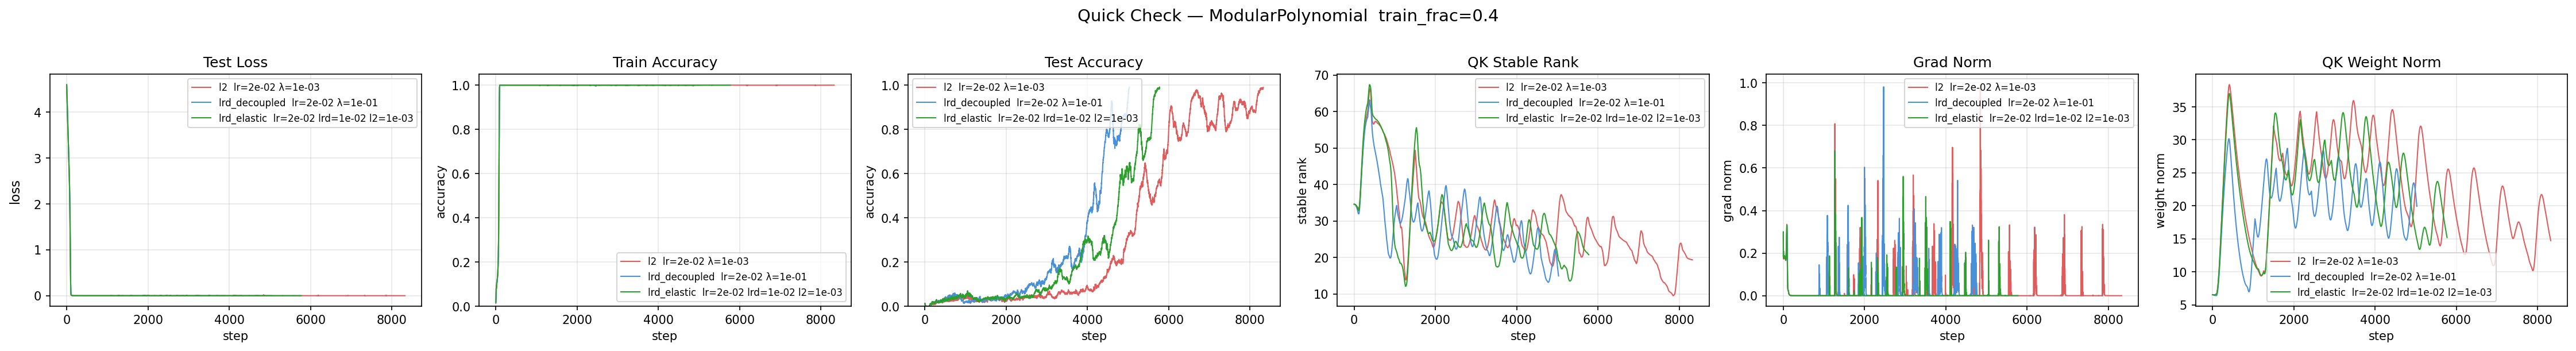 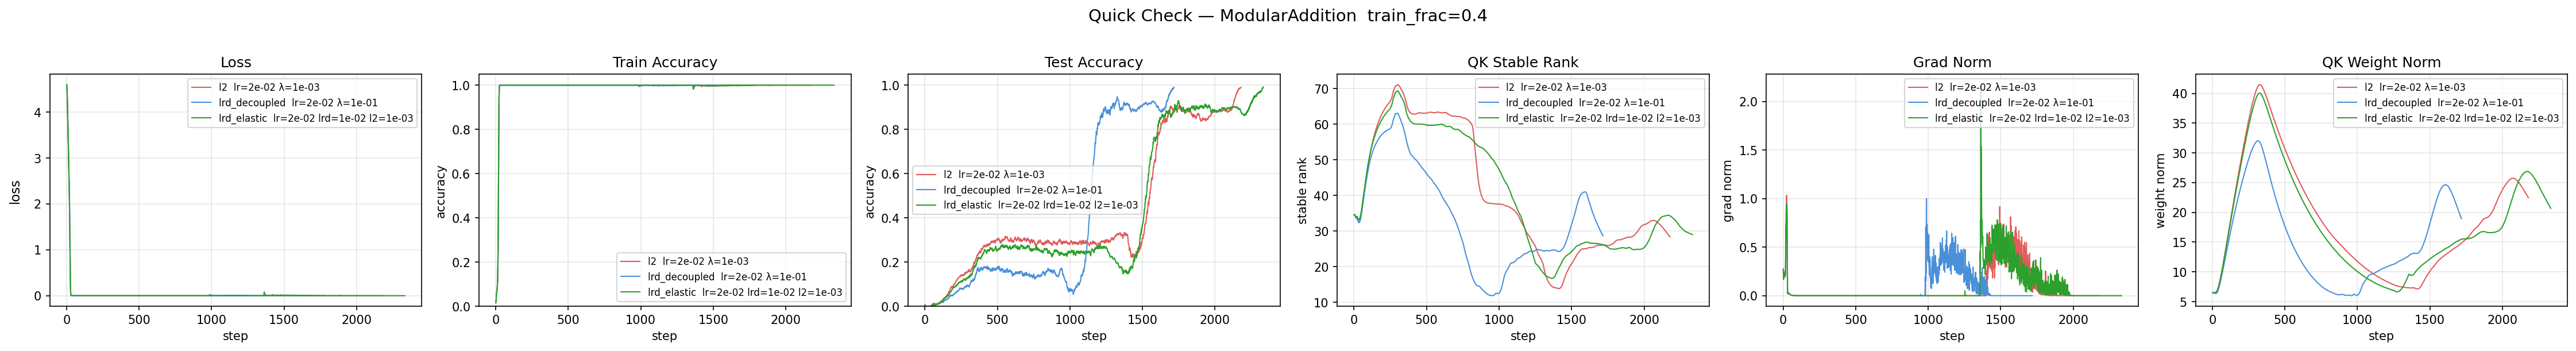 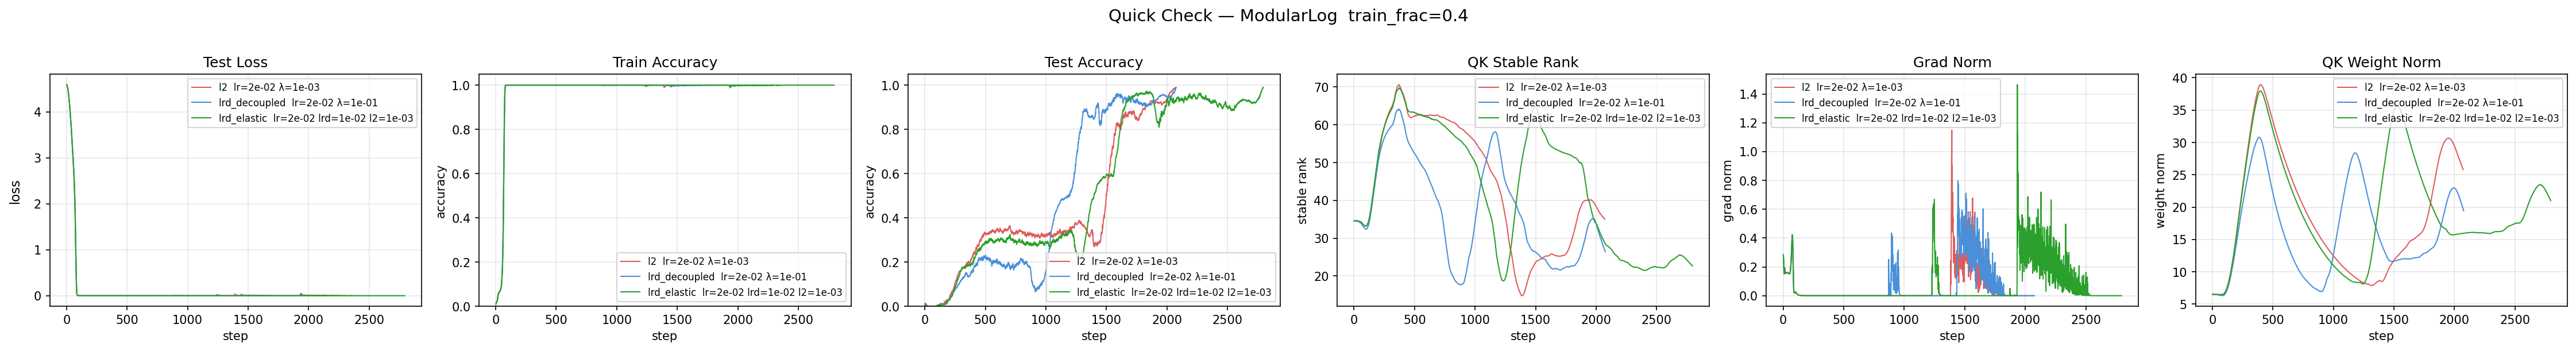

无显著优越性的结果：16位奇偶校验（三种方法均在500步内收敛）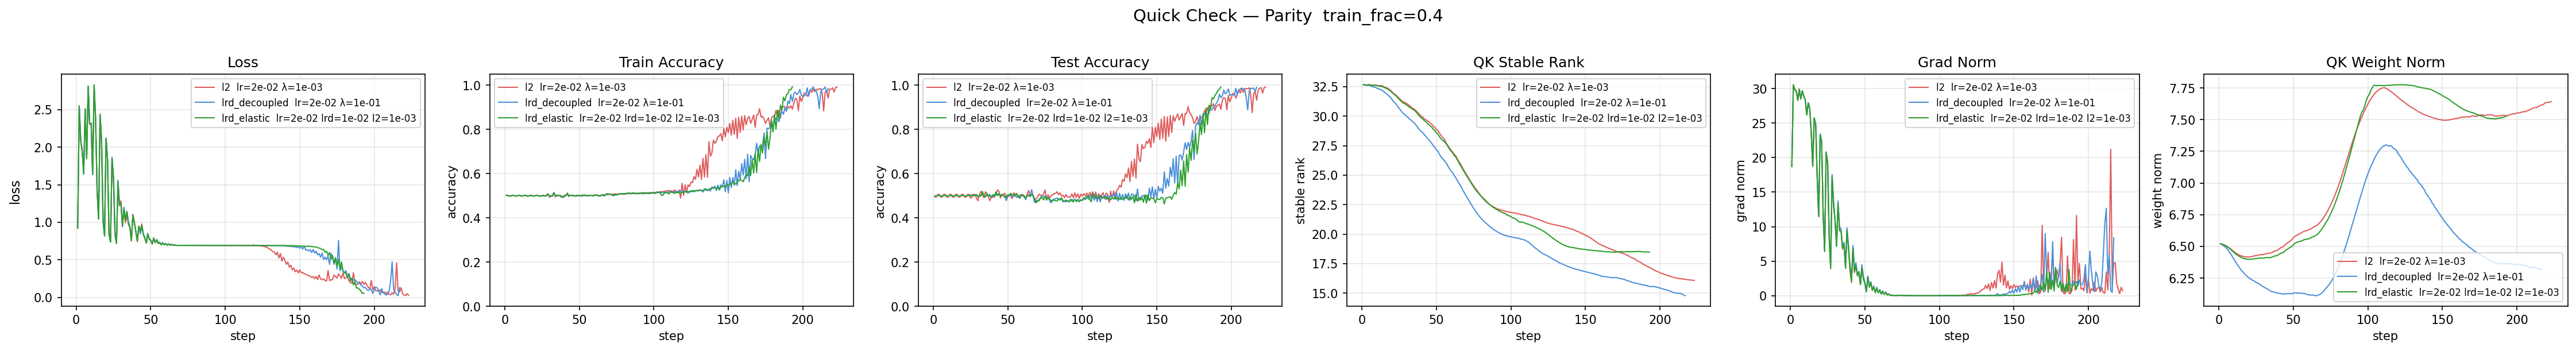!